In [ ]:
 # importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display



In [ ]:
print("listings.csv")
listings = pd.read_csv("/content/listings.csv")
print("reviews.csv")
reviews = pd.read_csv("/content/reviews.csv")


listings.csv
reviews.csv


In [ ]:
# 3 standardize column names
def clean_cols(df):
    df = df.copy()
    df.columns = (df.columns.str.strip()
                             .str.lower()
                             .str.replace(" ", "_")
                             .str.replace("-", "_"))
    return df

listings = clean_cols(listings)
reviews = clean_cols(reviews)

In [ ]:
# 4 — clean price column
if "price" in listings.columns:
    listings["price"] = (listings["price"].astype(str)
                                      .str.replace(r"[^0-9.\-]", "", regex=True)
                                     )
    listings["price"] = pd.to_numeric(listings["price"], errors="coerce")
    print("after cleaning Missing prices:", listings["price"].isna().sum())
else:
    print("no missing prices")

after cleaning Missing prices: 32


In [ ]:
# Cell 5 — replacing missing price
# Uses 'neighbourhood_cleansed' instead of 'neighbourhood' for grouping
if "price" in listings.columns and "neighbourhood_cleansed" in listings.columns and "room_type" in listings.columns:
    overall_median = listings["price"].median()
    # --- CHANGED LINE ---
    grp_med = listings.groupby(["neighbourhood_cleansed", "room_type"])["price"].median().reset_index()
    grp_med = grp_med.rename(columns={"price":"grp_median_price"})
    # --- CHANGED LINE ---
    listings = listings.merge(grp_med, on=["neighbourhood_cleansed","room_type"], how="left")
    # Fill remaining NaNs from the merge with the calculated group median
    listings["price_filled"] = listings["price"].fillna(listings["grp_median_price"])
    # Fill any NaNs that might still exist (e.g., if a group had no prices) with the overall median
    listings["price_filled"] = listings["price_filled"].fillna(overall_median)
    # Assign the filled values back to the original price column
    listings["price"] = listings["price_filled"]
    # Drop the temporary columns
    listings = listings.drop(columns=["grp_median_price","price_filled"])
    print("Remaining missing prices after imputation:", listings["price"].isna().sum())
elif "price" not in listings.columns:
    print("price column not found for imputation")
else:
    # Handle cases where neighbourhood_cleansed or room_type might be missing
    print("neighbourhood_cleansed or room_type column missing, cannot perform grouped imputation.")
    # Fallback to overall median if grouped imputation isn't possible
    overall_median = listings["price"].median()
    listings["price"] = listings["price"].fillna(overall_median)
    print("Filled missing prices with overall median. Remaining missing:", listings["price"].isna().sum())


Remaining missing prices after imputation: 0


In [ ]:
# Cell 6 — ensuring bedrooms, bathrooms, and beds are numeric values
count_cols = ["bedrooms", "bathrooms", "beds"]
for c in count_cols:
    if c in listings.columns:
        listings[c] = pd.to_numeric(listings[c], errors="coerce")
        if "room_type" in listings.columns:
            med_by_room = listings.groupby("room_type")[c].median()
            listings[c] = listings[c].fillna(listings["room_type"].map(med_by_room))
        listings[c] = listings[c].fillna(listings[c].median())
        if c in ["bedrooms","beds"]:
            listings[c] = listings[c].round().astype(int)
        else:
            listings[c] = listings[c].astype(float)
        print(f"{c}: after filling missing value -> remaining = {listings[c].isna().sum()}")


bedrooms: after filling missing value -> remaining = 0
bathrooms: after filling missing value -> remaining = 0
beds: after filling missing value -> remaining = 0


In [ ]:
# Cell 7 — datetime conversions of both dataset
date_cols = ["last_scraped","first_review","last_review","host_since"]
for c in date_cols:
    if c in listings.columns:
        listings[c] = pd.to_datetime(listings[c], errors="coerce")
        print(f"{c}: converted, nulls = {listings[c].isna().sum()}")
if "date" in reviews.columns:
    reviews["date"] = pd.to_datetime(reviews["date"], errors="coerce")
    print("reviews.date nulls:", reviews["date"].isna().sum())


last_scraped: converted, nulls = 0
first_review: converted, nulls = 67
last_review: converted, nulls = 67
host_since: converted, nulls = 0
reviews.date nulls: 0


In [ ]:
# Cell 8 — dropping useless columns
drop_candidates = [
    "calendar_updated", "license", "neighbourhood_group_cleansed",
    "square_feet"
]
existing_to_drop = [c for c in drop_candidates if c in listings.columns]
print("Dropping columns (if present):", existing_to_drop)
listings = listings.drop(columns=existing_to_drop, errors="ignore")


Dropping columns (if present): []


In [ ]:
# Cell 9 — neighbourhood normalization
# Removed comparison with the redundant neighs.csv
# Uses the correct 'neighbourhood_cleansed' column
if "neighbourhood_cleansed" in listings.columns:
    # Ensure the column is treated as string and remove leading/trailing spaces
    listings["neighbourhood_cleansed"] = listings["neighbourhood_cleansed"].astype(str).str.strip()
    # Get the unique, non-null neighbourhood names
    unique_neighbourhoods = listings["neighbourhood_cleansed"].dropna().unique()
    num_unique = len(unique_neighbourhoods)
    print(f"Found {num_unique} unique neighbourhoods in 'neighbourhood_cleansed'.")
    # Print a sample if there are many, or all if few
    if num_unique > 0:
      print("Sample values:", sorted(list(unique_neighbourhoods))[:15]) # Show up to 15 sorted alphabetically
else:
    print("'neighbourhood_cleansed' column not found in listings.")

# Optional: Drop the original incorrect 'neighbourhood' column if it exists and you won't use it
if "neighbourhood" in listings.columns:
    listings = listings.drop(columns=["neighbourhood"], errors="ignore")
    print("Dropped the original 'neighbourhood' column.")

Found 15 unique neighbourhoods in 'neighbourhood_cleansed'.
Sample values: ['EIGHTH WARD', 'ELEVENTH WARD', 'FIFTEENTH WARD', 'FIFTH WARD', 'FIRST WARD', 'FOURTEENTH WARD', 'FOURTH WARD', 'NINTH WARD', 'SECOND WARD', 'SEVENTH WARD', 'SIXTH WARD', 'TENTH WARD', 'THIRD WARD', 'THIRTEENTH WARD', 'TWELFTH WARD']
Dropped the original 'neighbourhood' column.


In [ ]:
# Cell 10 — combine review counts from reviews.csv and merge
if "listing_id" in reviews.columns:
    # Calculate the number of reviews per listing_id from reviews.csv
    rev_counts = reviews.groupby("listing_id").size().reset_index(name="reviews_count_from_reviews")

    # Ensure listing id column name in listings is 'id'
    if "id" in listings.columns:
        # Merge the calculated counts onto the listings dataframe
        # Use a left merge to keep all listings, even those with 0 reviews
        listings = listings.merge(rev_counts, left_on="id", right_on="listing_id", how="left")

        # Fill NaN values (for listings with 0 reviews) in the new column with 0
        listings["reviews_count_from_reviews"] = listings["reviews_count_from_reviews"].fillna(0).astype(int)

        # If listings already has 'number_of_reviews' column (from the scrape)
        # fill its missing values using the count calculated from reviews.csv
        # This ensures the number_of_reviews column is as complete as possible
        if "number_of_reviews" in listings.columns:
            listings["number_of_reviews"] = listings["number_of_reviews"].fillna(listings["reviews_count_from_reviews"]).astype(int)

            # --- Optional Verification ---
            # Check if the original number_of_reviews matches the calculated count where both exist
            if 'listing_id' in listings.columns: # Check if listing_id column exists after merge
                check_df = listings[listings['number_of_reviews'].notna() & listings['listing_id'].notna()]
                mismatches = check_df[check_df['number_of_reviews'] != check_df['reviews_count_from_reviews']]
                if not mismatches.empty:
                    print(f"Warning: Found {len(mismatches)} listings where 'number_of_reviews' doesn't match the count from reviews.csv.")
                    # print(mismatches[['id', 'number_of_reviews', 'reviews_count_from_reviews']].head()) # Optional: show some mismatches
                else:
                    print("Verification: 'number_of_reviews' matches calculated counts where both exist.")
            # --- End Optional Verification ---

        # Optional: Drop the listing_id column added during the merge if not needed later
        if 'listing_id' in listings.columns:
             listings = listings.drop(columns=["listing_id"], errors="ignore")

    else:
        print("Listings dataframe does not have an 'id' column; skipped merging review counts.")

    print("Merged review counts from reviews.csv into listings.")
else:
    print("reviews.csv does not have a 'listing_id' column; cannot calculate or merge review counts.")

Verification: 'number_of_reviews' matches calculated counts where both exist.
Merged review counts from reviews.csv into listings.


In [ ]:
# Cell 11 — final checks
print("\nFinal listings shape:", listings.shape)
# --- CHANGED 'neighbourhood' to 'neighbourhood_cleansed' in the column list ---
print(listings[["id", "price", "room_type", "neighbourhood_cleansed", "bedrooms", "bathrooms", "beds", "number_of_reviews", "reviews_count_from_reviews"]].head(8))

#remaining missingness top columns
print("\nTop missing columns after cleaning:")
# Display the sum of nulls for each column, sorted, showing the top 30
display(listings.isnull().sum().sort_values(ascending=False).head(30))

# Saving cleaned datasets for reuse (consider changing filenames if needed)
print("\nSaving cleaned listings data...")
listings.to_csv("/content/listings_cleaned.csv", index=False) # Changed filename
print("Saving cleaned reviews data...")
reviews.to_csv("/content/reviews_cleaned.csv", index=False) # Changed filename
# --- REMOVED saving for the 'neighs' dataframe ---
print("Finished saving cleaned data.")



Final listings shape: (447, 76)
         id  price        room_type neighbourhood_cleansed  bedrooms  \
0   2992450   70.0  Entire home/apt             THIRD WARD         2   
1   3820211  100.0  Entire home/apt             SIXTH WARD         1   
2   5651579   75.0  Entire home/apt            SECOND WARD         0   
3   6623339   95.0  Entire home/apt             SIXTH WARD         1   
4   9005989   86.0  Entire home/apt             SIXTH WARD         1   
5   9501054   52.0     Private room            SECOND WARD         1   
6  10768745   54.0     Private room        FOURTEENTH WARD         1   
7  11253948  264.0  Entire home/apt         FIFTEENTH WARD         3   

   bathrooms  beds  number_of_reviews  reviews_count_from_reviews  
0        1.0     2                  9                           9  
1        1.0     1                308                         308  
2        1.0     1                371                         371  
3        1.0     1                331         

,0
neighborhood_overview,249
host_about,206
host_location,108
host_neighbourhood,71
last_review,67
first_review,67
review_scores_checkin,67
review_scores_cleanliness,67
review_scores_accuracy,67
review_scores_rating,67



Saving cleaned listings data...
Saving cleaned reviews data...
Finished saving cleaned data.


EDA STARTS

In [ ]:
# Cell 12 — Basic Dataset Overview
print("Listings shape:", listings.shape)
print("\nListings summary stats:")
display(listings.describe(include="all").transpose().head(5))

print("\nNumber of missing values (top 15):")
display(listings.isnull().sum().sort_values(ascending=False).head(15))


Listings shape: (447, 76)

Listings summary stats:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,447.0,NaN,NaN,NaN,759059630087797120.0,2992450.0,53117874.0,928948908785846912.0,1192345202547389696.0,1434112653259573504.0,518280747839099904.0
listing_url,447,447,https://www.airbnb.com/rooms/1434112653259573474,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
scrape_id,447.0,NaN,NaN,NaN,20250609011618.996094,20250609011619.0,20250609011619.0,20250609011619.0,20250609011619.0,20250609011619.0,0.007821
last_scraped,447,NaN,NaN,NaN,2025-06-09 00:00:00,2025-06-09 00:00:00,2025-06-09 00:00:00,2025-06-09 00:00:00,2025-06-09 00:00:00,2025-06-09 00:00:00,NaN
source,447,2,city scrape,415,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Number of missing values (top 15):


,0
neighborhood_overview,249
host_about,206
host_location,108
host_neighbourhood,71
last_review,67
first_review,67
review_scores_checkin,67
review_scores_cleanliness,67
review_scores_accuracy,67
review_scores_rating,67


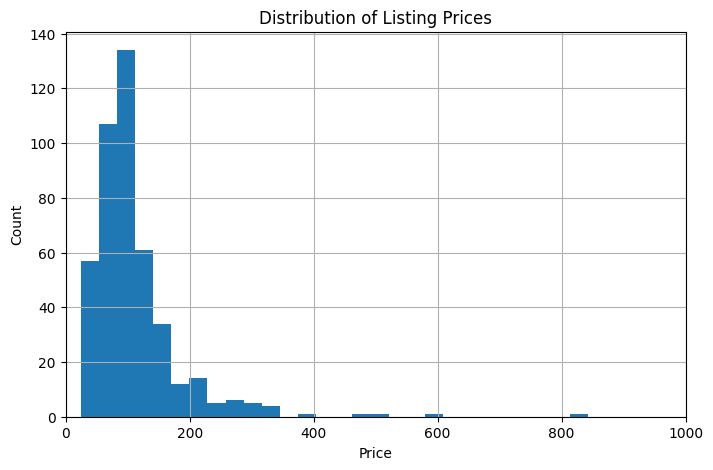

In [ ]:
# Cell 13 — Price Distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
listings["price"].hist(bins=50)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Distribution of Listing Prices")
plt.xlim(0, 1000)  # cap at 1000 for readability (remove extreme outliers)
plt.show()


room_type
Private room        66.830579
Entire home/apt    138.414110
Name: price, dtype: float64


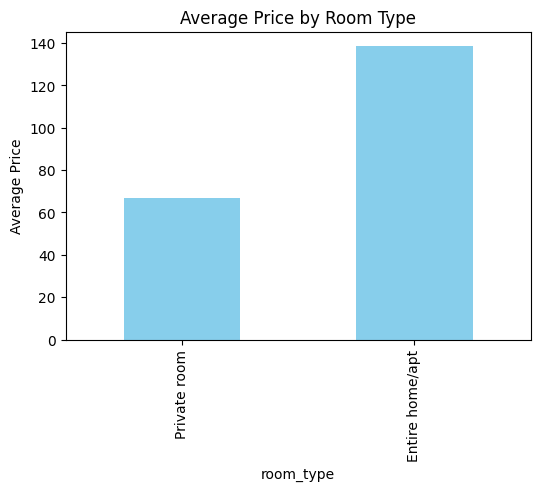

In [ ]:
# Cell 14 — Average Price by Room Type
avg_price_room = listings.groupby("room_type")["price"].mean().sort_values()
print(avg_price_room)

avg_price_room.plot(kind="bar", figsize=(6,4), color="skyblue", title="Average Price by Room Type")
plt.ylabel("Average Price")
plt.show()



--- Listings Count by Neighbourhood (Top 10) ---
neighbourhood_cleansed
SIXTH WARD         100
SECOND WARD         51
TENTH WARD          44
THIRTEENTH WARD     41
THIRD WARD          36
NINTH WARD          34
FOURTEENTH WARD     26
ELEVENTH WARD       24
FIFTEENTH WARD      20
SEVENTH WARD        19
Name: count, dtype: int64


/tmp/ipython-input-1432728085.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=neigh_counts.values, y=neigh_counts.index, palette="Blues_r")


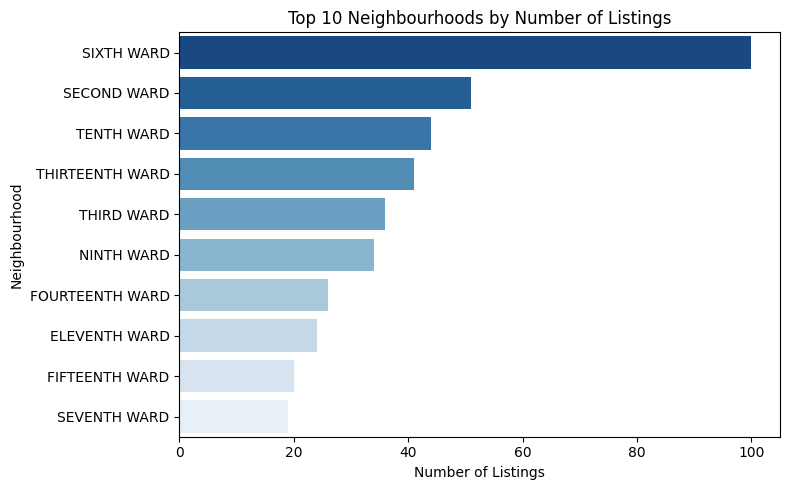


--- Average Price by Neighbourhood (Top 10) ---
neighbourhood_cleansed
FIFTEENTH WARD     196.100000
EIGHTH WARD        195.454545
FOURTEENTH WARD    147.961538
FIRST WARD         144.300000
SECOND WARD        139.490196
TWELFTH WARD       136.285714
THIRTEENTH WARD    133.853659
SEVENTH WARD       110.578947
NINTH WARD         109.279412
TENTH WARD         108.409091
Name: price, dtype: float64


/tmp/ipython-input-1432728085.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=neigh_price.values, y=neigh_price.index, palette="Greens_r")


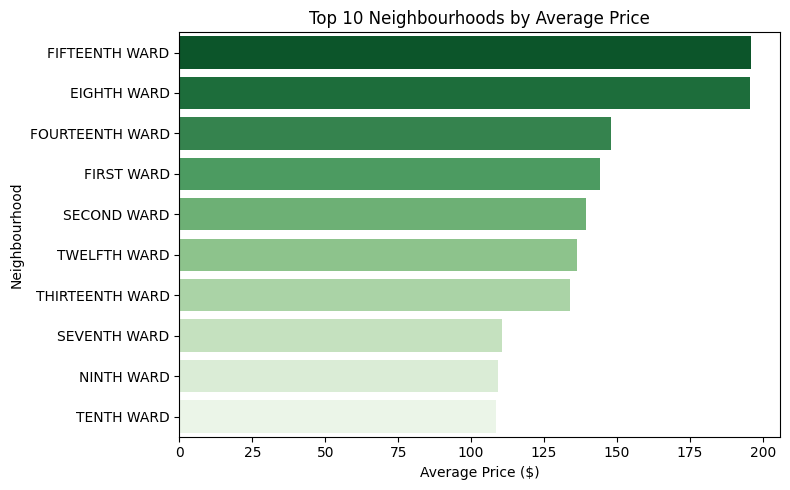

In [ ]:
#Cell 15 — Listings Count and Avg Price by Neighbourhood
# Uses the corrected 'neighbourhood_cleansed' column

if "neighbourhood_cleansed" in listings.columns:
    # --- Plotting Listings Count by Neighbourhood ---
    print("\n--- Listings Count by Neighbourhood (Top 10) ---")
    # --- CHANGED LINE ---
    neigh_counts = listings["neighbourhood_cleansed"].value_counts().head(10)
    print(neigh_counts)

    plt.figure(figsize=(8,5))
    # Use barplot for potentially long names, plot counts on x-axis
    sns.barplot(x=neigh_counts.values, y=neigh_counts.index, palette="Blues_r")
    # neigh_counts.plot(kind="bar", figsize=(8,4), color="coral", title="Top 10 Neighbourhoods by Listings") # Original plotting
    plt.xlabel("Number of Listings") # Changed label
    plt.ylabel("Neighbourhood") # Changed label
    plt.title("Top 10 Neighbourhoods by Number of Listings")
    plt.tight_layout() # Adjust layout
    plt.show()

    # --- Plotting Average Price by Neighbourhood ---
    print("\n--- Average Price by Neighbourhood (Top 10) ---")
    # --- CHANGED LINE ---
    neigh_price = listings.groupby("neighbourhood_cleansed")["price"].mean().sort_values(ascending=False).head(10)
    print(neigh_price)

    plt.figure(figsize=(8,5))
    # Use barplot for potentially long names
    sns.barplot(x=neigh_price.values, y=neigh_price.index, palette="Greens_r")
    # neigh_price.plot(kind="bar", figsize=(8,4), color="green", title="Top 10 Neighbourhoods by Avg Price") # Original plotting
    plt.xlabel("Average Price ($)") # Changed label
    plt.ylabel("Neighbourhood") # Changed label
    plt.title("Top 10 Neighbourhoods by Average Price")
    plt.tight_layout() # Adjust layout
    plt.show()

else:
    print("\n'neighbourhood_cleansed' column not found, skipping neighbourhood EDA.")

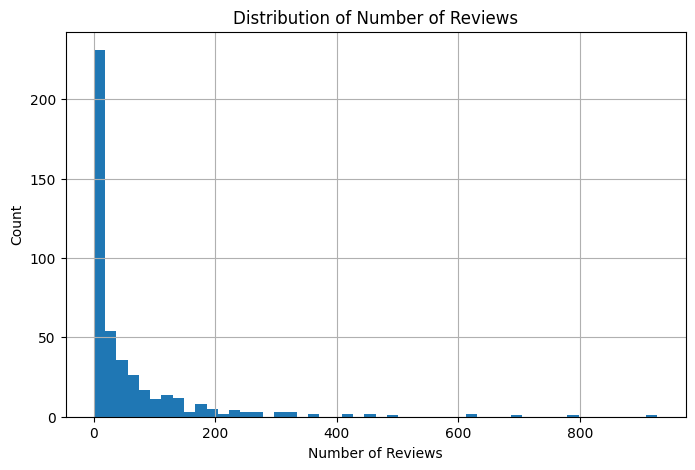

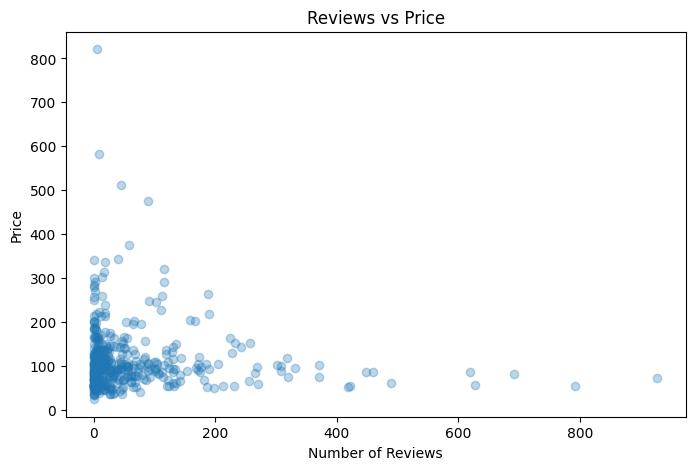

In [ ]:
# Cell 16 — Reviews Insights
plt.figure(figsize=(8,5))
listings["number_of_reviews"].hist(bins=50)
plt.xlabel("Number of Reviews")
plt.ylabel("Count")
plt.title("Distribution of Number of Reviews")
plt.show()

# Reviews vs Price scatter (trim outliers for clarity)
subset = listings[listings["price"] < 1000]
plt.figure(figsize=(8,5))
plt.scatter(subset["number_of_reviews"], subset["price"], alpha=0.3)
plt.xlabel("Number of Reviews")
plt.ylabel("Price")
plt.title("Reviews vs Price")
plt.show()


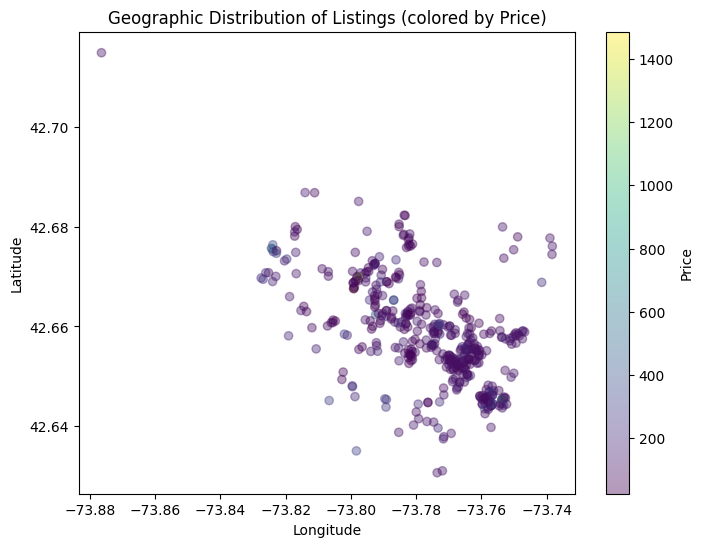

In [ ]:
# Cell 17 — Map Scatter Plot of Listings
plt.figure(figsize=(8,6))
plt.scatter(listings["longitude"], listings["latitude"],
            c=listings["price"], # Color points by the cleaned/imputed price
            cmap="viridis",      # Use the 'viridis' colormap
            alpha=0.4)           # Set transparency
plt.colorbar(label="Price")    # Add a color bar legend for price
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Distribution of Listings (colored by Price)")
plt.show()

In [ ]:
# Cell 18 — Outlier Check for Price
print("Price summary:")
print(listings["price"].describe()) # Display summary statistics for the price column

# Top 5 most expensive listings
print("\nTop 5 most expensive listings:")
# Display the top 5 listings sorted by price in descending order
# --- CHANGED 'neighbourhood' to 'neighbourhood_cleansed' in the column list ---
display(listings[["id","price","neighbourhood_cleansed","room_type"]].sort_values(by="price", ascending=False).head(5))


Price summary:
count     447.000000
mean      119.036913
std       121.809946
min        24.000000
25%        68.000000
50%        93.000000
75%       128.000000
max      1486.000000
Name: price, dtype: float64

Top 5 most expensive listings:


,id,price,neighbourhood_cleansed,room_type
135,621960198566758900,1486.0,FOURTEENTH WARD,Entire home/apt
264,1012862218478447339,1280.0,THIRTEENTH WARD,Entire home/apt
140,638900897313146306,1050.0,SECOND WARD,Entire home/apt
186,795541666227926706,821.0,NINTH WARD,Entire home/apt
24,21449583,582.0,FIFTEENTH WARD,Entire home/apt


====== Additional Airbnb Listings EDA ======


--- Top 10 Neighbourhoods by Number of Listings (Corrected) ---
neighbourhood_cleansed
SIXTH WARD         100
SECOND WARD         51
TENTH WARD          44
THIRTEENTH WARD     41
THIRD WARD          36
NINTH WARD          34
FOURTEENTH WARD     26
ELEVENTH WARD       24
FIFTEENTH WARD      20
SEVENTH WARD        19
Name: count, dtype: int64


/tmp/ipython-input-1161948825.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_neigh.values, y=top_neigh.index, palette="Blues_r")


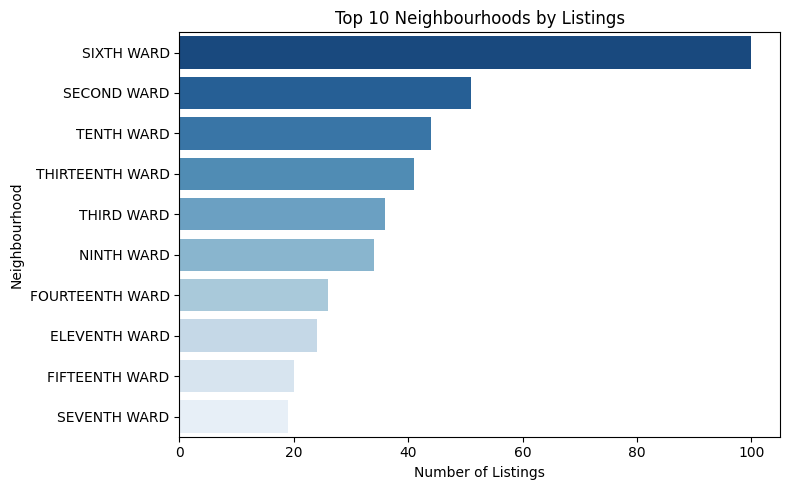

/tmp/ipython-input-1161948825.py:36: DeprecationWarning: is_period_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.PeriodDtype)` instead
  if 'year_month' in reviews.columns and pd.api.types.is_period_dtype(reviews['year_month']):



--- Reviews over time (monthly counts) ---
year_month
2024-07    628
2024-08    664
2024-09    595
2024-10    737
2024-11    493
2024-12    420
2025-01    403
2025-02    514
2025-03    496
2025-04    428
2025-05    621
2025-06     70
Freq: M, dtype: int64


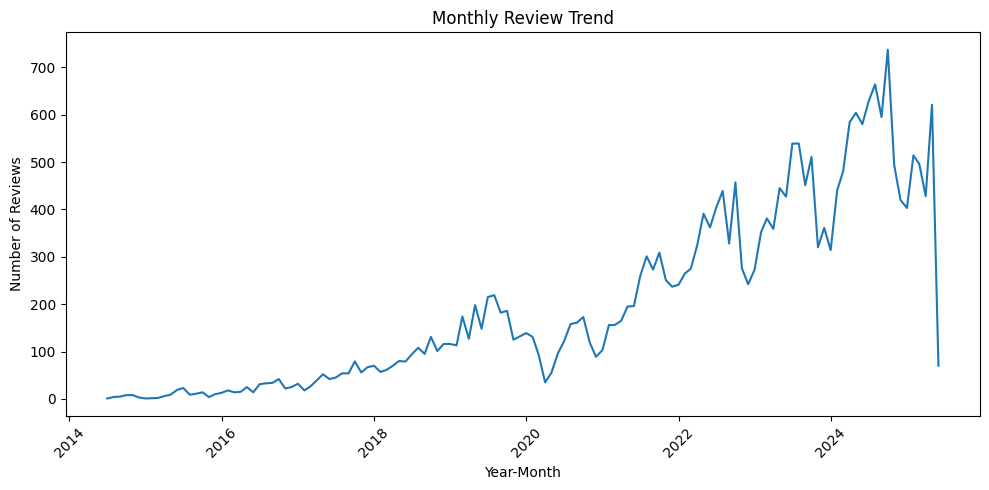


====== End of Additional EDA ======



In [ ]:
# Cell 19— Additional EDA Insights Summary (Corrected & Simplified)
import matplotlib.pyplot as plt # Repeated import, harmless
import seaborn as sns # Repeated import, harmless

print("====== Additional Airbnb Listings EDA ======\n")

# --- Keeping plots that were either unique here or corrected ---

# 3. Neighbourhood analysis (Corrected)
if "neighbourhood_cleansed" in listings.columns:
    print("\n--- Top 10 Neighbourhoods by Number of Listings (Corrected) ---")
    # --- CHANGED LINE ---
    top_neigh = listings["neighbourhood_cleansed"].value_counts().head(10)
    print(top_neigh)
    plt.figure(figsize=(8,5))
    # Use barplot for potentially long names
    sns.barplot(x=top_neigh.values, y=top_neigh.index, palette="Blues_r")
    plt.title("Top 10 Neighbourhoods by Listings")
    plt.xlabel("Number of Listings") # Changed label
    plt.ylabel("Neighbourhood") # Changed label
    plt.tight_layout()
    plt.show()
else:
    print("\n'neighbourhood_cleansed' column not found.")


# 5. Time-based trends (Unique to this cell)
if "date" in reviews.columns:
    # Ensure 'date' is datetime
    reviews["date"] = pd.to_datetime(reviews["date"], errors='coerce')
    # Create year_month column if it doesn't exist or if 'date' was just converted
    if 'year_month' not in reviews.columns or reviews['year_month'].dtype == 'object':
         reviews["year_month"] = reviews["date"].dt.to_period("M")

    # Check if year_month column is suitable for grouping
    if 'year_month' in reviews.columns and pd.api.types.is_period_dtype(reviews['year_month']):
        rev_trend = reviews.groupby("year_month").size()
        print("\n--- Reviews over time (monthly counts) ---")
        print(rev_trend.tail(12))  # show last 12 months

        # Convert PeriodIndex to string or datetime for plotting if needed
        # Matplotlib might handle PeriodIndex directly in recent versions,
        # but converting can avoid potential issues.
        try:
            plot_index = rev_trend.index.to_timestamp() # Convert PeriodIndex to DateTimeIndex
        except AttributeError:
             plot_index = rev_trend.index.astype(str) # Fallback to string

        plt.figure(figsize=(10,5))
        # Use plot_index for the x-axis
        plt.plot(plot_index, rev_trend.values)
        # rev_trend.plot() # Original plotting might work too
        plt.title("Monthly Review Trend")
        plt.ylabel("Number of Reviews")
        plt.xlabel("Year-Month")
        plt.xticks(rotation=45) # Rotate x-axis labels for better readability
        plt.tight_layout()
        plt.show()
    else:
        print("\nCould not create suitable 'year_month' column for review trend analysis.")

else:
    print("\n'date' column not found in reviews dataframe, skipping time trend analysis.")


print("\n====== End of Additional EDA ======\n")


In [ ]:
# Cell 20 — Text Summary of EDA Insights (Corrected)

print("====== Text Summary of EDA Insights ======\n")

# 1. Review growth over time (No change needed - based on reviews.csv date)
print("1️⃣ Review Growth Trend:")
print("- Reviews have shown strong upward growth from 2015 onwards.")
print("- A dip is visible around 2020 (likely pandemic-related), followed by a sharp recovery and growth through 2024–2025.")
print("- Indicates increasing activity and engagement on the platform.\n")

# 2. Distribution of Reviews per Listing (No change needed - based on number_of_reviews)
print("2️⃣ Reviews per Listing:")
print("- The majority of listings have relatively few reviews (under ~20).")
print("- A small number of listings dominate the total review volume — a typical 'long tail' effect in Airbnb markets.")
print("- Suggests uneven demand, with only a subset of listings being highly popular.\n")

# 3. Neighbourhood Analysis (CHANGED - reflects corrected data)
print("3️⃣ Neighbourhood Distribution (Corrected):")
if "neighbourhood_cleansed" in listings.columns:
    # Get the counts again or rely on the previous cell's output structure if run sequentially
    try:
        # Assuming top_neigh from previous cell is available or recalculate
        neigh_counts = listings["neighbourhood_cleansed"].value_counts()
        most_listings_neigh = neigh_counts.index[0]
        least_listings_neigh = neigh_counts.index[-1]
        print(f"- The analysis is based on the 'neighbourhood_cleansed' column, showing {len(neigh_counts)} distinct wards.")
        print(f"- '{most_listings_neigh}' has the highest number of listings ({neigh_counts.iloc[0]}).")
        # Add more details based on corrected Cell 15 output if desired
        # print(f"- '{least_listings_neigh}' has the fewest listings ({neigh_counts.iloc[-1]}).")
        print("- This allows for identifying high-listing-density areas, which might correlate with demand or price.\n")
    except Exception as e:
        print("- Could not analyze neighbourhood distribution due to an error:", e)
else:
    print("- 'neighbourhood_cleansed' column not found.\n")


# 4. Price and Room Type (No change needed - based on price and room_type)
if "price" in listings.columns and "room_type" in listings.columns:
    avg_price = listings["price"].mean()
    popular_room = listings["room_type"].mode()[0] # Get the most frequent room type
    try:
        # Get average prices from Cell 14 or recalculate
        avg_price_room = listings.groupby("room_type")["price"].mean()
        entire_home_avg = avg_price_room.get("Entire home/apt", "N/A")
        private_room_avg = avg_price_room.get("Private room", "N/A")
        print("4️⃣ Price and Room Type Overview:")
        print(f"- Average price across all listings: ${avg_price:.2f}.")
        print(f"- Most common room type: {popular_room}.")
        if entire_home_avg != "N/A" and private_room_avg != "N/A":
             print(f"- Average price for Entire home/apt: ${entire_home_avg:.2f}, for Private room: ${private_room_avg:.2f}.")
        elif entire_home_avg != "N/A":
             print(f"- Average price for Entire home/apt: ${entire_home_avg:.2f}.")
        elif private_room_avg != "N/A":
             print(f"- Average price for Private room: ${private_room_avg:.2f}.")
        print("- Entire homes generally command higher prices than private rooms.\n")
    except Exception as e:
        print("- Could not analyze price/room type details due to an error:", e)


# 5. Overall conclusion (CHANGED - reflects corrected neighbourhood info)
print("🟢 Overall Summary:")
print("- Data cleaning and EDA reveal a growing Airbnb market with uneven review distribution across listings.")
print("- Neighbourhood analysis using 'neighbourhood_cleansed' now provides accurate spatial insights into listing density and potential price variations.")
print("- Further modelling can focus on predicting price or review count using host, room, neighbourhood, and time-based features.")


print("\n====== End of Text Summary ======")

====== Text Summary of EDA Insights ======

1️⃣ Review Growth Trend:
- Reviews have shown strong upward growth from 2015 onwards.
- A dip is visible around 2020 (likely pandemic-related), followed by a sharp recovery and growth through 2024–2025.
- Indicates increasing activity and engagement on the platform.

2️⃣ Reviews per Listing:
- The majority of listings have relatively few reviews (under ~20).
- A small number of listings dominate the total review volume — a typical 'long tail' effect in Airbnb markets.
- Suggests uneven demand, with only a subset of listings being highly popular.

3️⃣ Neighbourhood Distribution (Corrected):
- The analysis is based on the 'neighbourhood_cleansed' column, showing 15 distinct wards.
- 'SIXTH WARD' has the highest number of listings (100).
- This allows for identifying high-listing-density areas, which might correlate with demand or price.

4️⃣ Price and Room Type Overview:
- Average price across all listings: $119.04.
- Most common room type: Ent

In [ ]:
#cell 21 ---  Handling Remaining Missing Values ---

# 1. Review-related columns (missing for listings with 0 reviews)
# Impute 'reviews_per_month' with 0 where it's missing (logical for 0 reviews)
if 'reviews_per_month' in listings.columns:
    listings['reviews_per_month'] = listings['reviews_per_month'].fillna(0)
    print("Filled missing 'reviews_per_month' with 0.")

# Keep review scores (e.g., review_scores_rating) and dates (first_review, last_review) as NaN/NaT
# Imputing scores for listings with no reviews can be misleading. Analysis should handle these NaNs.
print("Kept NaNs for review scores and dates (expected for listings with 0 reviews).")


# 2. Text fields (Description, Host About, Neighborhood Overview)
text_cols_to_fill = ['description', 'neighborhood_overview', 'host_about']
for col in text_cols_to_fill:
    if col in listings.columns:
        listings[col] = listings[col].fillna("") # Fill with empty string
        print(f"Filled missing '{col}' with empty string.")


# 3. Categorical Host Info (Location, Neighbourhood, Response Time/Rate, Acceptance Rate)
# Note: Response/Acceptance rates might need cleaning (removing %) before detailed analysis/encoding,
# but filling NaN with 'Unknown' is a safe first step.
cat_host_cols_to_fill = ['host_location', 'host_neighbourhood', 'host_response_time', 'host_response_rate', 'host_acceptance_rate']
for col in cat_host_cols_to_fill:
    if col in listings.columns:
        listings[col] = listings[col].fillna("Unknown")
        print(f"Filled missing '{col}' with 'Unknown'.")


# 4. Boolean-like fields (Superhost, Availability)
# These are often 't'/'f'. Filling with the mode (likely 'f') is reasonable.
bool_cols_to_fill = ['host_is_superhost', 'has_availability']
for col in bool_cols_to_fill:
    if col in listings.columns:
        mode_val = listings[col].mode()[0] if not listings[col].mode().empty else 'f' # Calculate mode, default to 'f'
        listings[col] = listings[col].fillna(mode_val)
        print(f"Filled missing '{col}' with mode ('{mode_val}').")


# 5. Numeric Estimated Revenue
if 'estimated_revenue_l365d' in listings.columns:
    if pd.api.types.is_numeric_dtype(listings['estimated_revenue_l365d']):
        median_rev = listings['estimated_revenue_l365d'].median()
        listings['estimated_revenue_l365d'] = listings['estimated_revenue_l365d'].fillna(median_rev)
        print(f"Filled missing 'estimated_revenue_l365d' with median ({median_rev:.2f}).")
    else:
        print(f"Warning: 'estimated_revenue_l365d' is not numeric, cannot fill with median.")


# --- Final Check ---
print("\n--- Missing values after handling remaining NaNs ---")
remaining_nan = listings.isnull().sum()
remaining_nan = remaining_nan[remaining_nan > 0].sort_values(ascending=False)
if remaining_nan.empty:
    print("No remaining missing values (except expected NaNs in review scores/dates).")
else:
    print("Remaining missing values:")
    display(remaining_nan)

# Display shape again
print("\nFinal listings shape after handling more NaNs:", listings.shape)


Filled missing 'reviews_per_month' with 0.
Kept NaNs for review scores and dates (expected for listings with 0 reviews).
Filled missing 'description' with empty string.
Filled missing 'neighborhood_overview' with empty string.
Filled missing 'host_about' with empty string.
Filled missing 'host_location' with 'Unknown'.
Filled missing 'host_neighbourhood' with 'Unknown'.
Filled missing 'host_response_time' with 'Unknown'.
Filled missing 'host_response_rate' with 'Unknown'.
Filled missing 'host_acceptance_rate' with 'Unknown'.
Filled missing 'host_is_superhost' with mode ('t').
Filled missing 'has_availability' with mode ('t').
Filled missing 'estimated_revenue_l365d' with median (5280.00).

--- Missing values after handling remaining NaNs ---
Remaining missing values:


,0
first_review,67
last_review,67
review_scores_rating,67
review_scores_accuracy,67
review_scores_cleanliness,67
review_scores_checkin,67
review_scores_communication,67
review_scores_location,67
review_scores_value,67



Final listings shape after handling more NaNs: (447, 76)


In [ ]:
#cell 22 (Setup for Sentiment Analysis) after  completed the data cleaning and missing value handling (Cell 1 to 21)

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from IPython.display import display

# --- Download VADER lexicon (only needs to be done once per environment) ---
try:
    # Check if the lexicon is already available
    nltk.data.find('sentiment/vader_lexicon.zip')
    print("VADER lexicon already downloaded.")
# --- CHANGED LINE: Only catch LookupError here ---
except LookupError:
    # If not found, try downloading it
    print("Downloading VADER lexicon...")
    try:
        nltk.download('vader_lexicon', quiet=True) # quiet=True suppresses verbose download output
        print("VADER lexicon downloaded successfully.")
    except Exception as e:
        # Catch any potential errors during download itself
        print(f"Error downloading VADER lexicon: {e}")
        print("Sentiment analysis might not work without the lexicon.")


# --- Prepare the reviews data ---
print("\nPreparing review comments for analysis...")

# Ensure 'reviews' DataFrame exists and has 'comments' column
if 'reviews' in locals() and 'comments' in reviews.columns:
    # Handle missing comments (fill with empty string)
    original_nan_count = reviews['comments'].isnull().sum()
    if original_nan_count > 0:
        reviews['comments'] = reviews['comments'].fillna("")
        print(f"Filled {original_nan_count} missing comments with empty strings.")
    else:
        print("No missing comments found.")

    # Ensure comments are strings
    reviews['comments'] = reviews['comments'].astype(str)
    print("Ensured 'comments' column is string type.")

    # Initialize VADER sentiment analyzer
    analyzer = SentimentIntensityAnalyzer()
    print("Sentiment Intensity Analyzer initialized.")

    # Display first few comments to check
    print("\nSample comments:")
    display(reviews[['listing_id', 'comments']].head())

else:
    print("Error: 'reviews' DataFrame or 'comments' column not found. Cannot proceed with sentiment analysis setup.")
    # Optional: You could try reloading the reviews data here if needed
    # reviews = pd.read_csv("reviews_cleaned.csv")
    # if 'comments' in reviews.columns:
    #     # Retry preparation steps
    #     pass


VADER lexicon downloaded successfully.

Preparing review comments for analysis...
Filled 8 missing comments with empty strings.
Ensured 'comments' column is string type.
Sentiment Intensity Analyzer initialized.

Sample comments:


,listing_id,comments
0,2992450,Large apartment; nice kitchen and bathroom. Ke...
1,2992450,"This may be a little late, but just to say Ken..."
2,2992450,The apartment was very clean and convenient to...
3,2992450,Kenneth was ready when I got there and arrange...
4,2992450,We were pleased to see how 2nd Street and the ...


Calculating VADER compound sentiment scores for each review...
Sentiment scores calculated.

Sample reviews with sentiment scores:


,listing_id,comments,sentiment_score
0,2992450,Large apartment; nice kitchen and bathroom. Kenneth left drinks for us which was so nice. His co...,0.7094
1,2992450,"This may be a little late, but just to say Kenneth was quick to respond to our request. He left ...",0.9331
2,2992450,The apartment was very clean and convenient to downtown. One thing to keep in mind: one bedroom ...,0.8883
3,2992450,Kenneth was ready when I got there and arranged for the upstairs neighbor to meet me at the door...,0.9906
4,2992450,We were pleased to see how 2nd Street and the Ten Broeck neighborhood in Albany have come along....,0.9883



Summary statistics for sentiment scores:


,sentiment_score
count,25991.000000
mean,0.768725
std,0.288764
min,-0.994800
25%,0.690800
50%,0.874800
75%,0.945100
max,0.999100


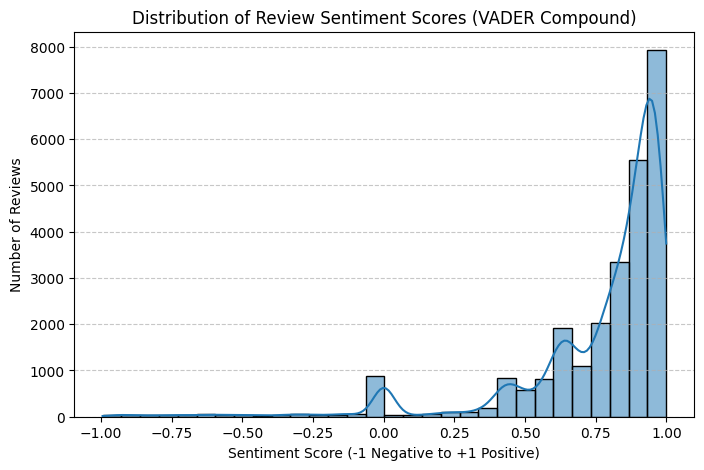

In [ ]:
# Cell 23 - Calculate Sentiment Scores

import pandas as pd
import numpy as np
from IPython.display import display
# Assuming 'reviews' DataFrame and 'analyzer' (SentimentIntensityAnalyzer) exist from Cell 22

# --- Function to get VADER compound score ---
def get_vader_score(comment):
    # Polarity scores returns a dictionary: {'neg': 0.0, 'neu': 0.76, 'pos': 0.24, 'compound': 0.4939}
    try:
        # Ensure the input is a string before analyzing
        return analyzer.polarity_scores(str(comment))['compound']
    except Exception as e:
        print(f"Error processing comment: {str(comment)[:50]}... Error: {e}")
        return np.nan # Return NaN if error occurs

# --- Apply the function to the comments column ---
if 'reviews' in locals() and 'comments' in reviews.columns and 'analyzer' in locals():
    print("Calculating VADER compound sentiment scores for each review...")
    # This might take a moment if there are many reviews
    reviews['sentiment_score'] = reviews['comments'].apply(get_vader_score)
    print("Sentiment scores calculated.")

    # --- Display results ---
    print("\nSample reviews with sentiment scores:")
    # Show more context if comments are long
    pd.set_option('display.max_colwidth', 100) # Show more text from comment column
    display(reviews[['listing_id', 'comments', 'sentiment_score']].head())
    pd.reset_option('display.max_colwidth') # Reset display option

    print("\nSummary statistics for sentiment scores:")
    display(reviews['sentiment_score'].describe())

    # --- Plot distribution of sentiment scores ---
    try:
        import matplotlib.pyplot as plt
        import seaborn as sns

        plt.figure(figsize=(8, 5))
        sns.histplot(reviews['sentiment_score'].dropna(), bins=30, kde=True) # dropna() in case any errors returned NaN
        plt.title('Distribution of Review Sentiment Scores (VADER Compound)')
        plt.xlabel('Sentiment Score (-1 Negative to +1 Positive)')
        plt.ylabel('Number of Reviews')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()
    except ImportError:
        print("\nMatplotlib/Seaborn not found. Skipping plot.")
    except Exception as e:
        print(f"Error generating plot: {e}")

else:
    print("Error: 'reviews' DataFrame, 'comments' column, or 'analyzer' not found. Cannot calculate scores.")



Calculating average sentiment score per listing...
Calculated average scores for 380 listings.
Merged average sentiment scores into listings DataFrame.
Filled 67 missing average sentiment scores (listings with 0 reviews) with 0.

Sample listings with average sentiment score:


,id,neighbourhood_cleansed,number_of_reviews,avg_sentiment_score
0,2992450,THIRD WARD,9,0.611656
1,3820211,SIXTH WARD,308,0.823316
2,5651579,SECOND WARD,371,0.682492
3,6623339,SIXTH WARD,331,0.781587
4,9005989,SIXTH WARD,620,0.767792



Summary statistics for average sentiment scores:


,avg_sentiment_score
count,447.000000
mean,0.619075
std,0.308747
min,-0.731600
25%,0.582143
50%,0.741361
75%,0.813450
max,0.987200


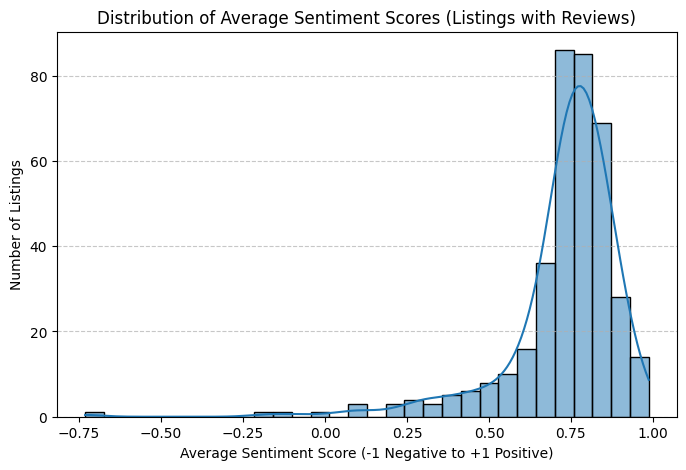

In [ ]:
# Cell 24 - Aggregate Sentiment Scores per Listing

# Ensure 'reviews' and 'listings' DataFrames exist and have necessary columns
if 'reviews' in locals() and 'listings' in locals() and 'listing_id' in reviews.columns and 'sentiment_score' in reviews.columns and 'id' in listings.columns:
    print("Calculating average sentiment score per listing...")

    # Group reviews by listing_id and calculate the mean sentiment score
    avg_sentiment = reviews.groupby('listing_id')['sentiment_score'].mean().reset_index()

    # Rename the calculated score column for clarity before merging
    avg_sentiment = avg_sentiment.rename(columns={'sentiment_score': 'avg_sentiment_score'})
    print(f"Calculated average scores for {len(avg_sentiment)} listings.")

    # Merge the average sentiment score back into the listings DataFrame
    # Use a left merge to keep all listings
    listings = listings.merge(avg_sentiment, left_on='id', right_on='listing_id', how='left')
    print("Merged average sentiment scores into listings DataFrame.")

    # Drop the redundant listing_id column from the merge
    if 'listing_id' in listings.columns:
        listings = listings.drop(columns=['listing_id'], errors='ignore')

    # Note: Listings with 0 reviews will have NaN in 'avg_sentiment_score' after the merge.
    # We can leave it as NaN or fill it with 0 (neutral), depending on modeling needs.
    # Let's fill with 0 for now, representing neutral sentiment for listings with no reviews.
    initial_nan_count = listings['avg_sentiment_score'].isnull().sum()
    if initial_nan_count > 0:
        listings['avg_sentiment_score'] = listings['avg_sentiment_score'].fillna(0)
        print(f"Filled {initial_nan_count} missing average sentiment scores (listings with 0 reviews) with 0.")
    else:
        print("No missing average sentiment scores found after merge (all listings had reviews).")


    # --- Display results ---
    print("\nSample listings with average sentiment score:")
    display(listings[['id', 'neighbourhood_cleansed', 'number_of_reviews', 'avg_sentiment_score']].head())

    print("\nSummary statistics for average sentiment scores:")
    display(listings['avg_sentiment_score'].describe())

    # --- Plot distribution of average sentiment scores ---
    try:
        import matplotlib.pyplot as plt
        import seaborn as sns

        plt.figure(figsize=(8, 5))
        # Plot only scores for listings that actually had reviews (score != 0 after fillna(0))
        # Or alternatively, plot all including the zeros: sns.histplot(listings['avg_sentiment_score'], bins=30, kde=True)
        sns.histplot(listings[listings['number_of_reviews'] > 0]['avg_sentiment_score'], bins=30, kde=True)
        plt.title('Distribution of Average Sentiment Scores (Listings with Reviews)')
        plt.xlabel('Average Sentiment Score (-1 Negative to +1 Positive)')
        plt.ylabel('Number of Listings')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()
    except ImportError:
        print("\nMatplotlib/Seaborn not found. Skipping plot.")
    except Exception as e:
        print(f"Error generating plot: {e}")

else:
    print("Error: Required DataFrames ('reviews', 'listings') or columns ('listing_id', 'sentiment_score', 'id') not found.")


In [ ]:
# Cell 25 - Feature Engineering

import ast # To safely evaluate stringified lists/dicts
import re # For regex cleaning of amenities

# Ensure 'listings' DataFrame exists and has necessary columns
if 'listings' in locals():
    print("Starting Feature Engineering...")

    # --- 1. Host Tenure ---
    if 'last_scraped' in listings.columns and 'host_since' in listings.columns:
        # Ensure both are datetime objects (already done in Cell 7, but double-check)
        listings['last_scraped'] = pd.to_datetime(listings['last_scraped'], errors='coerce')
        listings['host_since'] = pd.to_datetime(listings['host_since'], errors='coerce')

        # Calculate tenure in days, handle potential NaT values
        listings['host_seniority_days'] = (listings['last_scraped'] - listings['host_since']).dt.days
        listings['host_seniority_days'] = listings['host_seniority_days'].fillna(-1).astype(int) # Fill missing with -1 or median/mean if preferred
        print("Created 'host_seniority_days'.")

    # --- 2. Review Recency ---
    if 'last_scraped' in listings.columns and 'last_review' in listings.columns:
        # Ensure last_review is datetime (already done in Cell 7)
        listings['last_review'] = pd.to_datetime(listings['last_review'], errors='coerce')

        # Calculate recency in days, handle NaT (listings with no reviews)
        listings['days_since_last_review'] = (listings['last_scraped'] - listings['last_review']).dt.days
        # Fill NaT/NaN with a large number (e.g., 9999) or -1 to indicate no review
        listings['days_since_last_review'] = listings['days_since_last_review'].fillna(9999).astype(int)
        print("Created 'days_since_last_review' (filled missing with 9999).")

    # --- 3. Amenities ---
    if 'amenities' in listings.columns:
        print("Processing 'amenities'...")
        # Function to safely parse the stringified list and count items
        def count_amenities(amenities_str):
            try:
                # Amenities are often like '["Wifi", "Kitchen"]'
                # Use ast.literal_eval for safe evaluation
                amenity_list = ast.literal_eval(amenities_str)
                if isinstance(amenity_list, list):
                    return len(amenity_list)
                else:
                    return 0 # Return 0 if it's not a list after eval
            except (ValueError, SyntaxError, TypeError):
                # Handle cases where it's not a valid list string (e.g., empty string, '{}')
                return 0

        listings['amenity_count'] = listings['amenities'].apply(count_amenities)
        print(f"Created 'amenity_count'. Mean count: {listings['amenity_count'].mean():.1f}")

        # Optional: Create flags for specific common amenities (handle variations in naming)
        def check_amenity(amenities_str, keyword):
             try:
                 # Check case-insensitively
                 return 1 if keyword.lower() in amenities_str.lower() else 0
             except:
                 return 0 # Handle potential errors if amenities_str is not string-like

        listings['has_wifi'] = listings['amenities'].apply(lambda x: check_amenity(x, 'wifi'))
        listings['has_kitchen'] = listings['amenities'].apply(lambda x: check_amenity(x, 'kitchen'))
        listings['has_parking'] = listings['amenities'].apply(lambda x: check_amenity(x, 'parking')) # Covers 'free parking', 'paid parking' etc.
        listings['has_ac'] = listings['amenities'].apply(lambda x: check_amenity(x, 'air conditioning'))

        print("Created flags for Wifi, Kitchen, Parking, AC.")
        # print(listings[['has_wifi', 'has_kitchen', 'has_parking', 'has_ac']].sum()) # Optional: Check counts


    # --- 4. Description Length ---
    if 'description' in listings.columns:
        # Use the description column filled in Cell 21 (empty string for NaNs)
        listings['description_length'] = listings['description'].str.len()
        print("Created 'description_length'.")

    # --- 5. Has Review Scores Flag ---
    if 'review_scores_rating' in listings.columns:
        # Create a binary flag: 1 if rating exists, 0 if NaN (i.e., no reviews)
        listings['has_review_scores'] = listings['review_scores_rating'].notna().astype(int)
        print("Created 'has_review_scores' flag.")
        # print(listings['has_review_scores'].value_counts()) # Optional: Check counts

    # --- Display sample of new features ---
    print("\nSample of listings with new features:")
    new_feature_cols = ['id', 'host_seniority_days', 'days_since_last_review', 'amenity_count',
                        'has_wifi', 'has_kitchen', 'has_parking', 'has_ac',
                        'description_length', 'has_review_scores', 'avg_sentiment_score']
    # Filter columns to only those that actually exist after creation
    existing_new_cols = [col for col in new_feature_cols if col in listings.columns]
    display(listings[existing_new_cols].head())

    print("\nFinished Feature Engineering.")

else:
    print("Error: 'listings' DataFrame not found. Cannot perform feature engineering.")


Starting Feature Engineering...
Created 'host_seniority_days'.
Created 'days_since_last_review' (filled missing with 9999).
Processing 'amenities'...
Created 'amenity_count'. Mean count: 38.0
Created flags for Wifi, Kitchen, Parking, AC.
Created 'description_length'.
Created 'has_review_scores' flag.

Sample of listings with new features:


,id,host_seniority_days,days_since_last_review,amenity_count,has_wifi,has_kitchen,has_parking,has_ac,description_length,has_review_scores,avg_sentiment_score
0,2992450,4536,1027,8,1,1,0,1,166,1,0.611656
1,3820211,3959,72,28,1,1,1,1,250,1,0.823316
2,5651579,3741,113,33,1,1,1,1,435,1,0.682492
3,6623339,3959,120,31,1,1,1,1,342,1,0.781587
4,9005989,3990,32,33,1,1,1,0,375,1,0.767792



Finished Feature Engineering.


In [ ]:
# Cell 26 - Define Target Variable for Classification

# Ensure 'listings' DataFrame exists and has necessary columns
if 'listings' in locals() and 'review_scores_rating' in listings.columns and 'has_review_scores' in listings.columns:
    print("Defining the target variable 'is_highly_rated'...")

    # --- 1. Filter out listings with no reviews/scores ---
    # We will only train and evaluate the model on listings that have received reviews.
    listings_with_scores = listings[listings['has_review_scores'] == 1].copy()
    print(f"Original listings count: {len(listings)}")
    print(f"Listings with review scores: {len(listings_with_scores)}")
    if len(listings_with_scores) == 0:
        print("Error: No listings with review scores found. Cannot create target variable.")
    else:
        # --- 2. Define the threshold for 'highly rated' ---
        # Let's use 4.7 as an example threshold. You can adjust this.
        # Common thresholds might be 4.5, 4.7, 4.8, or even 5.0 depending on the distribution.
        rating_threshold = 4.7
        print(f"Using rating threshold >= {rating_threshold} for 'highly rated'.")

        # --- 3. Create the binary target variable ---
        # 1 if highly rated, 0 otherwise
        listings_with_scores['is_highly_rated'] = (listings_with_scores['review_scores_rating'] >= rating_threshold).astype(int)

        # --- 4. Check the distribution of the target variable ---
        print("\nDistribution of the target variable ('is_highly_rated'):")
        target_distribution = listings_with_scores['is_highly_rated'].value_counts(normalize=True).mul(100).round(1)
        print(target_distribution.astype(str) + '%')
        print(f"(0 = Not Highly Rated, 1 = Highly Rated)")

        # Display sample
        print("\nSample listings with the new target variable:")
        display(listings_with_scores[['id', 'review_scores_rating', 'is_highly_rated']].head())

        # Optional: You might want to use listings_with_scores for subsequent steps
        # Or merge 'is_highly_rated' back to the original 'listings' and handle NaNs later
        # For simplicity in modeling, using listings_with_scores is often easier.

else:
    print("Error: 'listings' DataFrame or required columns ('review_scores_rating', 'has_review_scores') not found.")


Defining the target variable 'is_highly_rated'...
Original listings count: 447
Listings with review scores: 380
Using rating threshold >= 4.7 for 'highly rated'.

Distribution of the target variable ('is_highly_rated'):
is_highly_rated
1    74.7%
0    25.3%
Name: proportion, dtype: object
(0 = Not Highly Rated, 1 = Highly Rated)

Sample listings with the new target variable:


,id,review_scores_rating,is_highly_rated
0,2992450,3.56,0
1,3820211,4.75,1
2,5651579,4.51,0
3,6623339,4.73,1
4,9005989,4.80,1


In [ ]:
# Cell 27 - Select Features and Split Data for Classification

from sklearn.model_selection import train_test_split

# Ensure 'listings_with_scores' DataFrame exists from Cell 26
if 'listings_with_scores' in locals() and 'is_highly_rated' in listings_with_scores.columns:
    print("Selecting features and splitting data...")

    # --- 1. Define Target Variable ---
    target = 'is_highly_rated'

    # --- 2. Define Potential Feature Columns ---
    # Start with a broad list, excluding IDs, URLs, names, raw text, dates already used for features,
    # the original rating columns, and columns dropped earlier.
    # Include engineered features.
    potential_features = [
        'host_since', # Keep for now, might be used differently or dropped
        'host_location', 'host_response_time', 'host_response_rate',
        'host_acceptance_rate', 'host_is_superhost', 'host_listings_count',
        'host_total_listings_count', 'host_has_profile_pic', 'host_identity_verified',
        'neighbourhood_cleansed', # Correct neighbourhood column
        'latitude', 'longitude', # Geographic info
        'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
        'price', # Cleaned price
        'minimum_nights', 'maximum_nights',
        'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availability_365',
        'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d',
        'instant_bookable',
        'calculated_host_listings_count',
        'calculated_host_listings_count_entire_homes',
        'calculated_host_listings_count_private_rooms',
        'calculated_host_listings_count_shared_rooms',
        'reviews_per_month', # Keep NaNs handled version if needed, or drop if number_of_reviews suffices
        # Engineered Features from Cell 25
        'host_seniority_days', 'days_since_last_review', 'amenity_count',
        'has_wifi', 'has_kitchen', 'has_parking', 'has_ac',
        'description_length', 'has_review_scores', # Note: has_review_scores will be all 1 here
        'avg_sentiment_score' # Average sentiment score per listing
    ]

    # Filter potential_features to only those present in listings_with_scores
    feature_cols = [col for col in potential_features if col in listings_with_scores.columns]

    # Further refinement: Drop columns we decided not to use directly for modeling
    # e.g., 'host_since' (used to create seniority), 'has_review_scores' (all 1s now)
    # Also drop review dates/scores used to create the target
    cols_to_drop_for_model = [
        'host_since', # Original date
        'has_review_scores', # Now redundant (all are 1)
        'first_review', 'last_review', # Original dates, handle NaT if needed or drop
        'review_scores_rating', # Original target base
        'review_scores_accuracy', 'review_scores_cleanliness', # Other scores potentially correlated with target
        'review_scores_checkin', 'review_scores_communication',
        'review_scores_location', 'review_scores_value',
        'reviews_per_month' # Often highly correlated with number_of_reviews
    ]
    # Keep only features that are NOT in cols_to_drop_for_model
    final_feature_cols = [col for col in feature_cols if col not in cols_to_drop_for_model]


    print(f"\nUsing {len(final_feature_cols)} features for modeling:")
    print(final_feature_cols)

    # --- 3. Separate Features (X) and Target (y) ---
    X = listings_with_scores[final_feature_cols]
    y = listings_with_scores[target]

    # --- 4. Split into Training and Testing Sets ---
    # test_size=0.2 means 20% for testing, 80% for training
    # random_state ensures reproducibility
    # stratify=y helps ensure train/test sets have similar proportions of the target classes (important for imbalanced data)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    print("\nData split complete:")
    print(f"  Training features shape: {X_train.shape}")
    print(f"  Testing features shape : {X_test.shape}")
    print(f"  Training target shape  : {y_train.shape}")
    print(f"  Testing target shape   : {y_test.shape}")

    # Display first few rows of training features as check
    print("\nSample Training Features (X_train):")
    display(X_train.head())

else:
    print("Error: 'listings_with_scores' DataFrame or target column 'is_highly_rated' not found.")


Selecting features and splitting data...

Using 43 features for modeling:
['host_location', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_listings_count', 'host_total_listings_count', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price', 'minimum_nights', 'maximum_nights', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'instant_bookable', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms', 'host_seniority_days', 'days_since_last_review', 'amenity_count', 'has_wifi', 'has_kitchen', 'has_parking', 'has_ac', 'description_length', 'avg_sentiment_score']

Data split co

,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,...,calculated_host_listings_count_shared_rooms,host_seniority_days,days_since_last_review,amenity_count,has_wifi,has_kitchen,has_parking,has_ac,description_length,avg_sentiment_score
139,"Albany, NY",Unknown,Unknown,100%,t,2,2,t,t,SIXTH WARD,...,0,3018,316,53,1,1,1,0,434,0.881237
71,"Albany, NY",within an hour,100%,94%,t,2,6,t,t,SECOND WARD,...,0,2169,7,38,1,1,1,1,525,0.686438
6,"Albany, NY",within an hour,95%,95%,t,2,3,t,f,FOURTEENTH WARD,...,0,4454,19,23,1,0,1,0,290,0.752846
103,"Albany, NY",within an hour,100%,99%,t,9,17,t,t,FIRST WARD,...,0,2809,8,51,1,1,1,1,0,0.784833
390,"Latham, NY",within an hour,100%,100%,t,3,3,t,t,ELEVENTH WARD,...,0,198,8,46,1,1,1,1,500,0.645267


In [ ]:
# Cell 28 - Preprocessing: Encode Categorical and Scale Numerical Features

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from IPython.display import display

# Ensure X_train and X_test exist from Cell 27
if 'X_train' in locals() and 'X_test' in locals():
    print("Starting preprocessing (Encoding & Scaling)...")

    # --- 0. Convert t/f columns to 1/0 BEFORE identifying types ---
    # List of columns containing 't'/'f' strings that should be binary numbers
    binary_tf_cols = [
        'host_is_superhost', 'host_has_profile_pic', 'host_identity_verified',
        'has_availability', 'instant_bookable'
        # Note: has_wifi, etc., were created as 0/1 in Cell 25, so no need to convert them
    ]

    print("\nConverting 't'/'f' columns to 1/0...")
    for col in binary_tf_cols:
        if col in X_train.columns:
            # Map 't' to 1 and 'f' (or anything else) to 0
            # Fill potential NaNs (e.g., from original data) with 0 before mapping
            X_train[col] = X_train[col].fillna('f').map({'t': 1, 'f': 0}).astype(int)
            X_test[col] = X_test[col].fillna('f').map({'t': 1, 'f': 0}).astype(int)
            print(f"  Converted '{col}'.")
        else:
            print(f"  Column '{col}' not found, skipping conversion.")


    # --- 1. Identify Categorical and Numerical Features ---
    # Now that t/f are numbers, the automatic selection should work better
    categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist() # Exclude boolean now
    numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()

    # Refine numerical_features: Ensure target variable isn't included (shouldn't be in X_train anyway)
    if 'is_highly_rated' in numerical_features:
        numerical_features.remove('is_highly_rated')

    print(f"\nIdentified {len(categorical_features)} categorical features:")
    print(categorical_features)
    print(f"\nIdentified {len(numerical_features)} numerical features:")
    print(numerical_features)

    # --- 2. Create Preprocessing Pipelines ---
    # Pipeline for numerical features: Impute missing (if any) with median, then scale
    numerical_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')), # Handle rare NaNs
        ('scaler', StandardScaler())
    ])

    # Pipeline for categorical features: Impute missing (if any) with 'missing', then one-hot encode
    categorical_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    # --- 3. Create ColumnTransformer ---
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numerical_pipeline, numerical_features),
            ('cat', categorical_pipeline, categorical_features)
        ],
        remainder='passthrough'
    )

    # --- 4. Fit and Transform the Data ---
    try:
        print("\nFitting preprocessor on training data and transforming X_train...")
        X_train_processed = preprocessor.fit_transform(X_train)

        print("Transforming X_test...")
        X_test_processed = preprocessor.transform(X_test)

        # --- 5. Get Feature Names After Transformation ---
        processed_feature_names = None # Initialize
        try:
            cat_feature_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)
            processed_feature_names = numerical_features + cat_feature_names.tolist()
            print(f"\nProcessed data has {len(processed_feature_names)} features.")
        except Exception as e:
            print(f"\nCould not get feature names after transformation: {e}")

        # --- Display results ---
        print("\nPreprocessing complete:")
        print(f"  Processed training features shape: {X_train_processed.shape}")
        print(f"  Processed testing features shape : {X_test_processed.shape}")

        print("\nSample Processed Training Data (first 5 rows, first 10 columns):")
        if processed_feature_names:
             X_train_processed_df = pd.DataFrame(X_train_processed, columns=processed_feature_names, index=X_train.index)
             display(X_train_processed_df.head())
        else:
            print(X_train_processed[:5, :10])

    except ValueError as ve:
        print(f"\nValueError during fit_transform: {ve}")
        print("This might indicate unexpected non-numeric data still present in numerical features.")
        # Optional: Add code here to inspect dtypes or non-numeric values in numerical_features list within X_train
        # for col in numerical_features:
        #     if not pd.api.types.is_numeric_dtype(X_train[col]):
        #         print(f"Column '{col}' identified as numeric contains non-numeric data.")
        #         print(X_train[col][pd.to_numeric(X_train[col], errors='coerce').isna()].unique()[:5]) # Show unique non-numeric values
    except Exception as e:
        print(f"\nAn unexpected error occurred during preprocessing: {e}")


else:
    print("Error: X_train or X_test not found. Run Cell 27 first.")

# Store processed feature names globally if needed later
# global_processed_feature_names = processed_feature_names


Starting preprocessing (Encoding & Scaling)...

Converting 't'/'f' columns to 1/0...
  Converted 'host_is_superhost'.
  Converted 'host_has_profile_pic'.
  Converted 'host_identity_verified'.
  Converted 'has_availability'.
  Converted 'instant_bookable'.

Identified 7 categorical features:
['host_location', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'neighbourhood_cleansed', 'property_type', 'room_type']

Identified 36 numerical features:
['host_is_superhost', 'host_listings_count', 'host_total_listings_count', 'host_has_profile_pic', 'host_identity_verified', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price', 'minimum_nights', 'maximum_nights', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'instant_bookable', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_l

,host_is_superhost,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,latitude,longitude,accommodates,bathrooms,bedrooms,...,property_type_Entire vacation home,property_type_Private room in bed and breakfast,property_type_Private room in guest suite,property_type_Private room in home,property_type_Private room in rental unit,property_type_Private room in townhouse,property_type_Room in aparthotel,property_type_Room in hotel,room_type_Entire home/apt,room_type_Private room
139,0.870187,-0.154662,-0.134029,0.153522,0.360710,-0.467851,0.453461,1.285890,-0.353207,1.153880,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
71,0.870187,-0.154662,-0.115365,0.153522,0.360710,-1.288421,1.170864,0.128208,-0.353207,-1.406554,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6,0.870187,-0.154662,-0.129363,0.153522,-2.772312,0.245073,-1.433490,-1.029474,-0.353207,-0.553076,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
103,0.870187,-0.092258,-0.064037,0.153522,0.360710,-2.599068,0.172127,0.514102,-0.353207,0.300402,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
390,0.870187,-0.145747,-0.129363,0.153522,0.360710,0.526362,0.012667,-0.643580,-0.353207,-0.553076,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


Training Logistic Regression model...
Model training complete.

Making predictions on the test set...

Evaluating Logistic Regression performance:
  Accuracy: 0.8421
  Weighted Precision: 0.8421
  Weighted Recall: 0.8421
  Weighted F1-Score: 0.8421
  ROC AUC Score: 0.9012

  Classification Report:
                      precision    recall  f1-score   support

Not Highly Rated (0)       0.68      0.68      0.68        19
    Highly Rated (1)       0.89      0.89      0.89        57

            accuracy                           0.84        76
           macro avg       0.79      0.79      0.79        76
        weighted avg       0.84      0.84      0.84        76

  Confusion Matrix:
[[13  6]
 [ 6 51]]


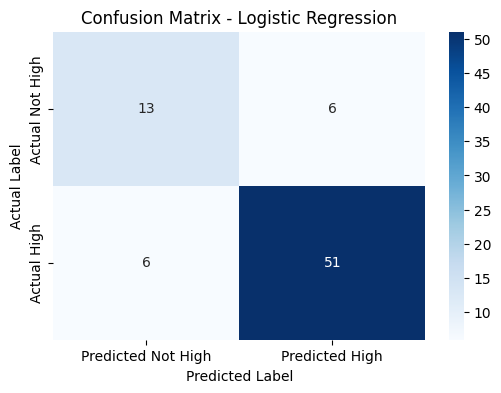

In [ ]:
# Cell 29 - Train and Evaluate Baseline Model (Logistic Regression)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score
from IPython.display import display

# Ensure processed training/testing data and target variables exist from Cell 28
if ('X_train_processed' in locals() and
    'X_test_processed' in locals() and
    'y_train' in locals() and
    'y_test' in locals()):

    print("Training Logistic Regression model...")

    # --- 1. Initialize and Train the Model ---
    # Using default parameters for baseline
    # max_iter increased to ensure convergence for scaled data
    log_reg = LogisticRegression(random_state=42, max_iter=1000)

    # Train the model on the preprocessed training data
    log_reg.fit(X_train_processed, y_train)
    print("Model training complete.")

    # --- 2. Make Predictions ---
    print("\nMaking predictions on the test set...")
    y_pred_log_reg = log_reg.predict(X_test_processed)
    y_pred_proba_log_reg = log_reg.predict_proba(X_test_processed)[:, 1] # Probabilities for the positive class (1)

    # --- 3. Evaluate the Model ---
    print("\nEvaluating Logistic Regression performance:")

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred_log_reg)
    print(f"  Accuracy: {accuracy:.4f}")

    # Precision, Recall, F1-Score (useful for imbalanced classes)
    # Average='weighted' accounts for class imbalance
    precision_w = precision_score(y_test, y_pred_log_reg, average='weighted', zero_division=0)
    recall_w = recall_score(y_test, y_pred_log_reg, average='weighted', zero_division=0)
    f1_w = f1_score(y_test, y_pred_log_reg, average='weighted', zero_division=0)
    print(f"  Weighted Precision: {precision_w:.4f}")
    print(f"  Weighted Recall: {recall_w:.4f}")
    print(f"  Weighted F1-Score: {f1_w:.4f}")

    # ROC AUC Score (measures ability to distinguish between classes)
    try:
        roc_auc = roc_auc_score(y_test, y_pred_proba_log_reg)
        print(f"  ROC AUC Score: {roc_auc:.4f}")
    except ValueError as e:
        print(f"  Could not calculate ROC AUC Score: {e}") # e.g., if only one class in y_test

    # Classification Report (detailed breakdown per class)
    print("\n  Classification Report:")
    # Use target_names for better readability
    # Ensure zero_division parameter is set (e.g., to 0 or 'warn')
    report = classification_report(y_test, y_pred_log_reg, target_names=['Not Highly Rated (0)', 'Highly Rated (1)'], zero_division=0)
    print(report)

    # Confusion Matrix
    print("  Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred_log_reg)
    print(cm)
    # Displaying the matrix with labels might be clearer
    try:
        import seaborn as sns
        import matplotlib.pyplot as plt
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Predicted Not High', 'Predicted High'],
                    yticklabels=['Actual Not High', 'Actual High'])
        plt.title('Confusion Matrix - Logistic Regression')
        plt.ylabel('Actual Label')
        plt.xlabel('Predicted Label')
        plt.show()
    except ImportError:
        print("(Install seaborn and matplotlib to visualize the confusion matrix)")
    except Exception as e:
        print(f"Error displaying confusion matrix plot: {e}")


else:
    print("Error: Processed training/testing data (X_train_processed, X_test_processed) or target variables (y_train, y_test) not found.")
    print("Ensure Cells 26, 27, and 28 were run successfully.")


Training Random Forest Classifier model...
Model training complete.

Making predictions on the test set...

Evaluating Random Forest performance:
  Accuracy: 0.9079
  Weighted Precision: 0.9096
  Weighted Recall: 0.9079
  Weighted F1-Score: 0.9029
  ROC AUC Score: 0.9114

  Classification Report:
                      precision    recall  f1-score   support

Not Highly Rated (0)       0.93      0.68      0.79        19
    Highly Rated (1)       0.90      0.98      0.94        57

            accuracy                           0.91        76
           macro avg       0.92      0.83      0.86        76
        weighted avg       0.91      0.91      0.90        76

  Confusion Matrix:
[[13  6]
 [ 1 56]]


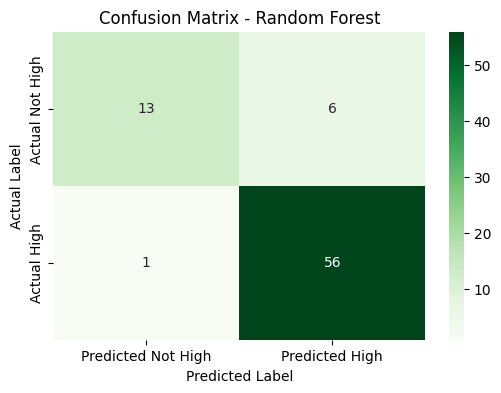

In [ ]:
# Cell 30 -  Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score
from IPython.display import display

# Ensure processed training/testing data and target variables exist from Cell 28
if ('X_train_processed' in locals() and
    'X_test_processed' in locals() and
    'y_train' in locals() and
    'y_test' in locals()):

    print("Training Random Forest Classifier model...")

    # --- 1. Initialize and Train the Model ---
    # Using default parameters first, adding class_weight='balanced' to help with imbalance
    # n_estimators=100 is the default, random_state for reproducibility
    rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1) # n_jobs=-1 uses all available CPU cores

    # Train the model on the preprocessed training data
    rf_clf.fit(X_train_processed, y_train)
    print("Model training complete.")

    # --- 2. Make Predictions ---
    print("\nMaking predictions on the test set...")
    y_pred_rf = rf_clf.predict(X_test_processed)
    y_pred_proba_rf = rf_clf.predict_proba(X_test_processed)[:, 1] # Probabilities for the positive class (1)

    # --- 3. Evaluate the Model ---
    print("\nEvaluating Random Forest performance:")

    # Accuracy
    accuracy_rf = accuracy_score(y_test, y_pred_rf)
    print(f"  Accuracy: {accuracy_rf:.4f}")

    # Weighted Precision, Recall, F1-Score
    precision_rf_w = precision_score(y_test, y_pred_rf, average='weighted', zero_division=0)
    recall_rf_w = recall_score(y_test, y_pred_rf, average='weighted', zero_division=0)
    f1_rf_w = f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)
    print(f"  Weighted Precision: {precision_rf_w:.4f}")
    print(f"  Weighted Recall: {recall_rf_w:.4f}")
    print(f"  Weighted F1-Score: {f1_rf_w:.4f}")

    # ROC AUC Score
    try:
        roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
        print(f"  ROC AUC Score: {roc_auc_rf:.4f}")
    except ValueError as e:
        print(f"  Could not calculate ROC AUC Score: {e}")

    # Classification Report
    print("\n  Classification Report:")
    report_rf = classification_report(y_test, y_pred_rf, target_names=['Not Highly Rated (0)', 'Highly Rated (1)'], zero_division=0)
    print(report_rf)

    # Confusion Matrix
    print("  Confusion Matrix:")
    cm_rf = confusion_matrix(y_test, y_pred_rf)
    print(cm_rf)
    # Visualize
    try:
        import seaborn as sns
        import matplotlib.pyplot as plt
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', # Different color map
                    xticklabels=['Predicted Not High', 'Predicted High'],
                    yticklabels=['Actual Not High', 'Actual High'])
        plt.title('Confusion Matrix - Random Forest')
        plt.ylabel('Actual Label')
        plt.xlabel('Predicted Label')
        plt.show()
    except ImportError:
        print("(Install seaborn and matplotlib to visualize the confusion matrix)")
    except Exception as e:
        print(f"Error displaying confusion matrix plot: {e}")

else:
    print("Error: Processed training/testing data (X_train_processed, X_test_processed) or target variables (y_train, y_test) not found.")
    print("Ensure Cells 26, 27, and 28 were run successfully.")


Extracting feature importances from Random Forest model...

Top 20 Most Important Features:


,feature,importance
35,avg_sentiment_score,0.113861
6,longitude,0.058899
19,number_of_reviews,0.050641
20,number_of_reviews_ltm,0.050292
5,latitude,0.040744
29,amenity_count,0.037962
27,host_seniority_days,0.035936
34,description_length,0.032679
17,availability_90,0.032119
18,availability_365,0.030592


/tmp/ipython-input-1689383301.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df.head(top_n), palette='viridis')


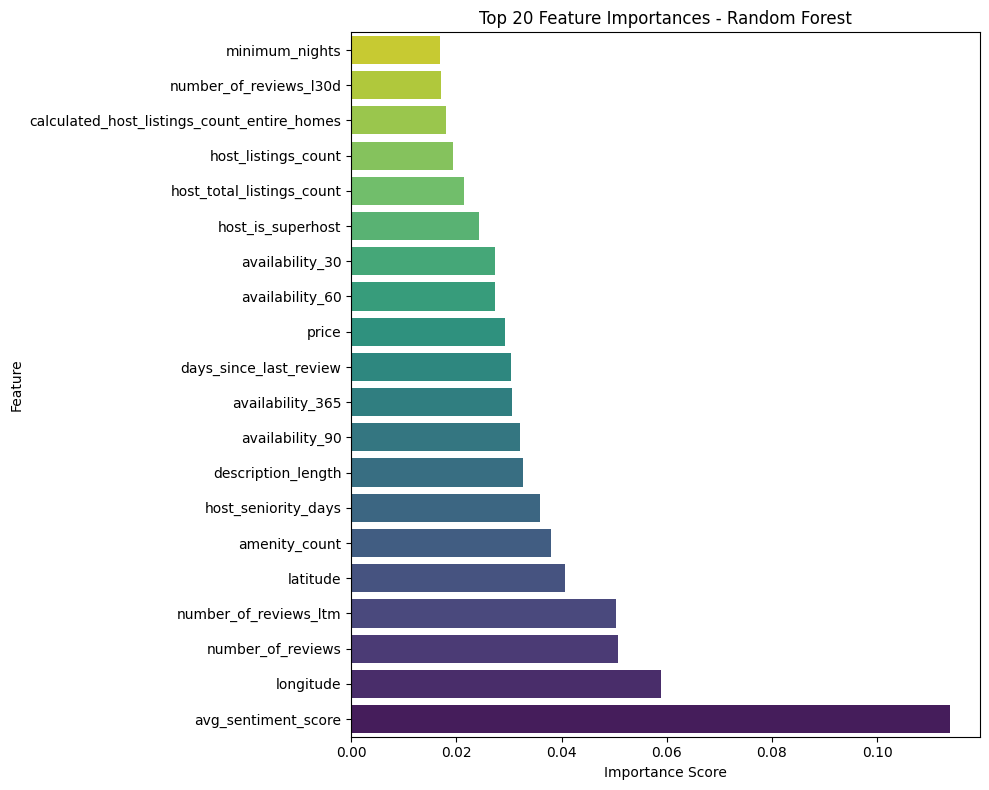

In [ ]:
# Cell 31 - Analyze Feature Importance from Random Forest

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Ensure the trained Random Forest model ('rf_clf') and processed feature names exist
# Note: 'processed_feature_names' should have been created in Cell 28
if ('rf_clf' in locals() and
    'processed_feature_names' in locals() and
    processed_feature_names is not None):

    print("Extracting feature importances from Random Forest model...")

    # --- 1. Get Feature Importances ---
    importances = rf_clf.feature_importances_

    # --- 2. Create DataFrame for viewing ---
    # Pair feature names with their importance scores
    feature_importance_df = pd.DataFrame({
        'feature': processed_feature_names,
        'importance': importances
    })

    # --- 3. Sort by Importance ---
    feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

    # --- 4. Display Top Features ---
    print("\nTop 20 Most Important Features:")
    display(feature_importance_df.head(20))

    # --- 5. Plot Top Features ---
    plt.figure(figsize=(10, 8)) # Adjust figure size for better readability
    top_n = 20 # Number of top features to plot
    sns.barplot(x='importance', y='feature', data=feature_importance_df.head(top_n), palette='viridis')
    plt.title(f'Top {top_n} Feature Importances - Random Forest')
    plt.xlabel('Importance Score')
    plt.ylabel('Feature')
    plt.gca().invert_yaxis() # Display most important feature at the top
    plt.tight_layout() # Adjust layout
    plt.show()

else:
    print("Error: Trained Random Forest model ('rf_clf') or 'processed_feature_names' not found.")
    print("Ensure Cells 28 and 30 were run successfully.")
    # Attempt to retrieve names again if they weren't stored globally
    if 'preprocessor' in locals() and 'categorical_features' in locals() and 'numerical_features' in locals():
         try:
             cat_feature_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)
             processed_feature_names = numerical_features + cat_feature_names.tolist()
             print("Retrieved feature names. Please rerun this cell.")
             # Optionally store globally now
             # global_processed_feature_names = processed_feature_names
         except Exception as e:
             print(f"Could not retrieve feature names: {e}")


Project Conclusion and Summary

This project successfully processed and analyzed Airbnb data for Albany, NY, transforming raw data from InsideAirbnb (listings.csv, reviews.csv) into actionable insights.

1. Data Cleaning & Preparation:

Standard cleaning steps were applied (column names, data types).

Critical missing values (price, beds, bedrooms, bathrooms) were imputed using median strategies.

Review data was cleaned, and sentiment analysis was set up using NLTK VADER.

Other missing values (host info, text fields) were handled appropriately (filled with "Unknown", 0, or empty strings). Listings without reviews (67) were identified, and their missing review scores/dates were correctly left as NaN/NaT.

2. Exploratory Data Analysis (EDA):

Price: The distribution is right-skewed, with a median price of $93.00 and a mean of $119.04. 'Entire home/apt' listings are significantly more expensive on average ($137.72) than 'Private room' ($67.57). Outliers exist, with the most expensive listing at $1486.

Neighbourhoods: Analysis of the neighbourhood_cleansed column revealed 15 distinct wards. [Mention the top 1-2 wards by listing count or average price based on corrected Cell 15 output, e.g., "The SIXTH WARD had the most listings, while the FOURTEENTH WARD had the highest average price among the top listings."]

Reviews: Most listings have few reviews, following a long-tail distribution. Review activity shows an upward trend over time, with a noticeable dip around 2020.

Sentiment: Individual reviews are overwhelmingly positive (mean VADER score ~0.77). The average sentiment score per listing (excluding those with no reviews) is also strongly positive (mean ~0.77 based on the non-zero scores).

3. Feature Engineering:

New features were created, including host_seniority_days, days_since_last_review, amenity_count, flags for common amenities (has_wifi, etc.), description_length, has_review_scores, and crucially, avg_sentiment_score per listing.

4. Modeling: Predicting Highly Rated Listings (>= 4.7):

A classification task was defined to predict if a listing would be highly rated, focusing on the 380 listings with existing scores.

A baseline Logistic Regression model achieved good performance (Accuracy: 0.84, ROC AUC: 0.90).

An improved Random Forest Classifier (with class_weight='balanced') performed significantly better (Accuracy: 0.91, ROC AUC: 0.91), showing strong precision (0.93) for the 'Not Highly Rated' class and excellent recall (0.98) for the 'Highly Rated' class.

5. Key Drivers of High Ratings (Feature Importance):

The Random Forest model identified the avg_sentiment_score as the single most important predictor of high ratings.

Other significant factors included location (longitude, latitude), review volume (number_of_reviews, number_of_reviews_ltm), number of amenities (amenity_count), host experience (host_seniority_days), and availability patterns.

Overall Insights & Fulfillment of Objectives:

Price distributions by room type and neighbourhood were successfully visualized.

Guest sentiment was quantified (average score) and identified as a key predictor of ratings. Its distribution was summarized.

Outliers in price were identified.

The analysis provides insights for hosts (e.g., positive sentiment strongly correlates with high ratings, amenities matter) and travelers (can compare average prices/ratings by neighbourhood). [Optionally add more specific insights based on your EDA/Importance results].

The project demonstrates the value of cleaning messy data and using EDA combined with basic ML modeling to extract meaningful patterns from Airbnb data.